## Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

**Due: Sunday, October 4, 2026, at 11:59 PM ET**

There is a grace period until **2:00 AM ET**. After that, late submissions are penalized **10% for each 24-hour period**. After **5 days**, the score is 0.

In this assignment, you will use a modern pretrained CNN, **MobileNetV2**, to classify the **Intel Image Dataset**, which contains 6 scene classes.

You will begin by using MobileNetV2 as a **frozen feature extractor**, training only a new classification head. You will then explore progressively more flexible transfer-learning strategies by making all or part of the pretrained backbone trainable.

To make experimentation practical, the notebook provides a `DATA_FRACTION` setting. During development, you may use a smaller fraction of the dataset to test ideas and compare configurations more quickly. Before recording your final results, set:

```python
DATA_FRACTION = 1.0
```

and rerun the complete notebook using the full dataset.

Because MobileNetV2 was pretrained on ImageNet, the images are processed using `mobilenet_v2.preprocess_input`, which scales the input pixels to the range expected by the pretrained network.

The goal is to understand **why transfer learning works**, how to design a useful **classification head**, and how choices such as **learning rate**, **learning-rate control with `ReduceLROnPlateau`**, **regularization**, and **which pretrained layers are allowed to change** affect model performance.

### Learning Objectives

By the end of this homework, you should be able to:

* Use a pretrained CNN as a **frozen feature extractor**.
* Design and compare different **classification heads** on top of a pretrained backbone.
* Experiment efficiently using a reduced dataset before running final models on the full dataset.
* Understand the difference between a **frozen backbone** and making some or all pretrained layers trainable.
* Use practical training controls including:

  * fixed **learning rates**,
  * `ReduceLROnPlateau`,
  * `EarlyStopping`,
  * **Dropout** and **L2 regularization**,
  * and **Batch Normalization** in classification heads.
* Compare strategies that make:

  * the **entire backbone** trainable,
  * only the **last N layers** trainable,
  * or only the **top K MobileNetV2 blocks** trainable.

### Baseline Model

The starting backbone is:

```python
MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

With `pooling="avg"`, MobileNetV2 already applies **Global Average Pooling** and outputs a **1280-dimensional feature vector** for each image.

The baseline classification head consists of a single:

```python
Dense(num_classes, activation="softmax")
```

layer for the 6 Intel classes.

**Do not add another pooling layer when `pooling="avg"` is used.**

### The Five Problems

1. **Problem 1 — Frozen Backbone:**
   Keep MobileNetV2 frozen and redesign only the **classification head**. Try at least three head designs and experiment with training hyperparameters.

2. **Problem 2 — Fully Trainable Backbone:**
   Use one of your best head architectures from Problem 1, make the **entire MobileNetV2 backbone trainable**, and experiment with appropriately small learning rates and other training choices.

3. **Problem 3 — Unfreeze the Last N Layers:**
   Keep most of MobileNetV2 frozen while allowing only the **last N layers** to be updated.

4. **Problem 4 — Unfreeze the Top K Blocks:**
   Instead of selecting individual layers, make only the **top K MobileNetV2 blocks or stages** trainable and compare the results.

5. **Problem 5 -- Final Reflection**

Use your **HW4 CNN results as a reference point**. Transfer learning may or may not outperform every model you developed in HW4; the important goal is to understand how the different transfer-learning strategies affect training behavior and model performance.



## 1. Setup and Data Loading


In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


/usr/local/python/3.14.2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1791340104.962844    1934 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791340133.217937    1934 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 0.25

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 8
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



E0000 00:00:1791340153.867322    1934 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 2807 val examples: 699 test examples: 748
train per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 481, 'mountain': 503, 'sea': 455, 'street': 476}
val per-class counts: {'buildings': 109, 'forest': 113, 'glacier': 120, 'mountain': 125, 'sea': 113, 'street': 119}
test per-class counts: {'buildings': 109, 'forest': 118, 'glacier': 138, 'mountain': 131, 'sea': 127, 'street': 125}


InvalidArgumentError: {{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} slice index 8 of dimension 0 out of bounds. [Op:StridedSlice] name: strided_slice/

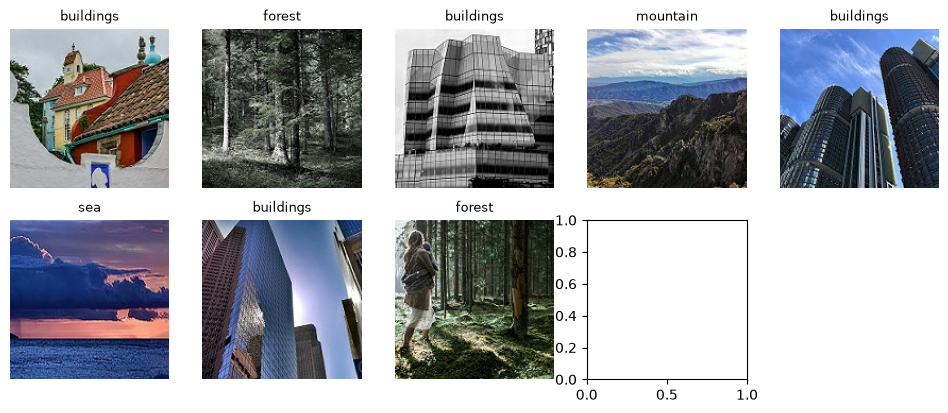

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Convert MobileNetV2 [-1, 1] values back to [0, 1] for display
    img = (images[i].numpy() + 1.0) / 2.0

    plt.imshow(img)
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Learning Rate Schedulers

In [8]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight CNN pretrained on the ImageNet dataset. We will use it as a source of high-quality visual features rather than training a convolutional network from scratch.

See the **Appendix** for additional information about `MobileNetV2`.

The baseline model defined below uses `MobileNetV2` as a frozen **feature extractor**. With `include_top=False` and built-in **Global Average Pooling**, the backbone produces a 1280-dimensional feature vector for each image.

The images have already been processed using `mobilenet_v2.preprocess_input`, which scales the pixel values to the range expected by the pretrained MobileNetV2 weights.

> **NOTE:** The standard MobileNetV2 ImageNet weights are associated with 224×224 images. We use 150×150 images to reduce training time. This is valid because, with `include_top=False`, the convolutional backbone can operate on different input image sizes.
>
> Keras may therefore issue a warning such as:
>
> `UserWarning: input_shape is undefined or non-square, ...`
>
> You may safely ignore this warning for this assignment.


In [9]:
# ALWAYS construct a new instance to avoid sharing layers across models.

def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
        pooling="avg",
    )
    base.trainable = trainable
    return base


base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/tmp/ipykernel_1934/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [10]:
# Ha, this is very long!

# base.summary()

/tmp/ipykernel_1934/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500


/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 131ms/step - accuracy: 0.8180 - loss: 0.4893 - val_accuracy: 0.8755 - val_loss: 0.3292
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.9127 - loss: 0.2467 - val_accuracy: 0.8741 - val_loss: 0.3408
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 111ms/step - accuracy: 0.9305 - loss: 0.1883 - val_accuracy: 0.8670 - val_loss: 0.3427
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - accuracy: 0.9480 - loss: 0.1478 - val_accuracy: 0.8798 - val_loss: 0.3456
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.9633 - loss: 0.1150 - val_accuracy: 0.8712 - val_loss: 0.3840
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9647 - loss: 0.1008 - val_accuracy: 0.8741 - val_loss: 0.3800
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9751 - loss: 0.0801 - val_accuracy: 0.8784 - val_loss: 0.3913
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9808 - loss: 0.0684 -

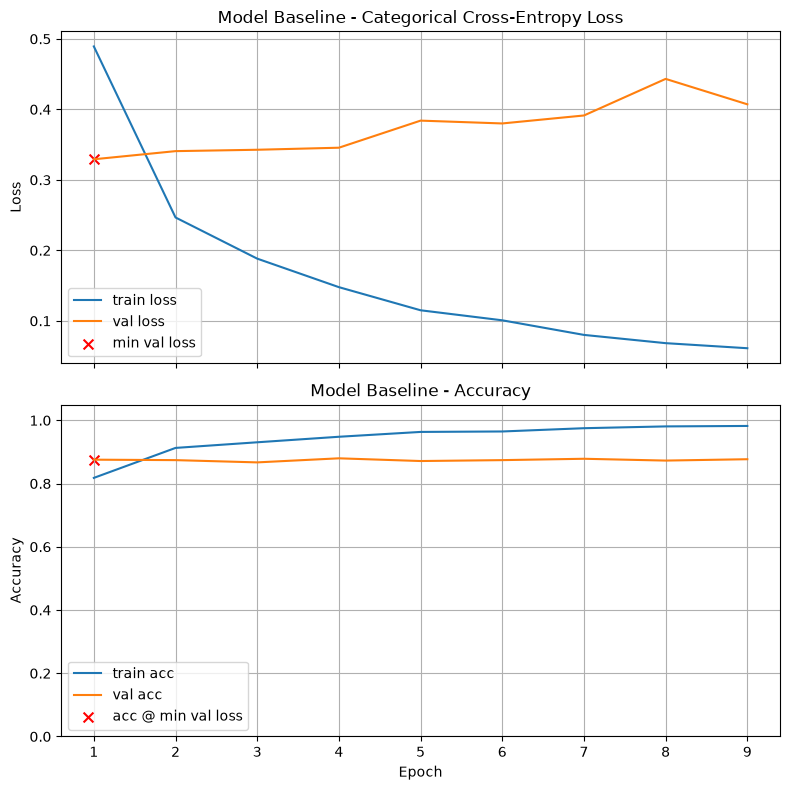

Final Training Loss:            0.0612
Final Training Accuracy:        0.9822
Final Validation Loss:          0.4072
Final Validation Accuracy:      0.8770
Minimum Validation Loss:        0.3292 (Epoch 1)
Validation Accuracy @ Min Loss: 0.8755

Test Loss: 0.2933
Test Accuracy: 0.8957

Validation-Test Gap (accuracy): 0.020185

Execution Time: 00:05:50


In [11]:
# Construct a fresh frozen MobileNetV2 backbone

base_model = make_base_model_pooled()

model_baseline = models.Sequential([
    base_model,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_baseline, title="Model Baseline")

### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and try to improve accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_model_pooled(
    trainable=False
)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D feature vector** for each image.

Do **not** unfreeze any backbone layers, and do **not** add another pooling layer.

### To Do

1. **Ask an AI helper** (e.g., ChatGPT):

   *“What are some more complex classification heads that could improve this model on the Intel Image Classification Dataset, without unfreezing the MobileNetV2 backbone?”*

2. **Implement at least three different head designs.** These may be AI-suggested or inspired by techniques used in HW4.

3. **Experiment with hyperparameters** for the different designs, such as:

   * learning rate
   * `EarlyStopping` settings
   * Dropout and/or L2 regularization
   * `ReduceLROnPlateau` on or off

4. **Train and compare** the three head designs using a reduced value of `DATA_FRACTION`.

   Use these runs to compare architectures and training behavior and to narrow down a reasonable final configuration.

5. **Select one configuration**, set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this full-data run when answering the graded questions.

6. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the backbone output has shape **(None, 1280)**, so **do not add `GlobalAveragePooling2D()`** to the head.
* `BatchNormalization` may be used within the classification head.
* Keep the entire MobileNetV2 backbone frozen for all experiments in this problem.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.



/tmp/ipykernel_23578/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Head 1 — Dense 256 + Dropout

Epoch 1/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 54s 557ms/step - accuracy: 0.7998 - loss: 0.5739 - val_accuracy: 0.8870 - val_loss: 0.3106
Epoch 2/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 480ms/step - accuracy: 0.9002 - loss: 0.2784 - val_accuracy: 0.8670 - val_loss: 0.3588
Epoch 3/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 486ms/step - accuracy: 0.9223 - loss: 0.2105 - val_accuracy: 0.8956 - val_loss: 0.3246
Epoch 4/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 484ms/step - accuracy: 0.9341 - loss: 0.1746 - val_accuracy: 0.8898 - val_loss: 0.3310
Epoch 5/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 81s 469ms/step - accuracy: 0.9441 - loss: 0.1541 - val_accuracy: 0.8913 - val_loss: 0.3401
Epoch 6/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 483ms/step - accuracy: 0.9558 - loss: 0.1181 - val_accuracy: 0.8856 - val_loss: 0.3515
Epoch 7/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 40s 456ms/step - accuracy: 0.9629 - loss: 0.1070 - val_accuracy: 0.8827 - val_loss: 0.3649
Epoch 8/500
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 505ms/step - acc

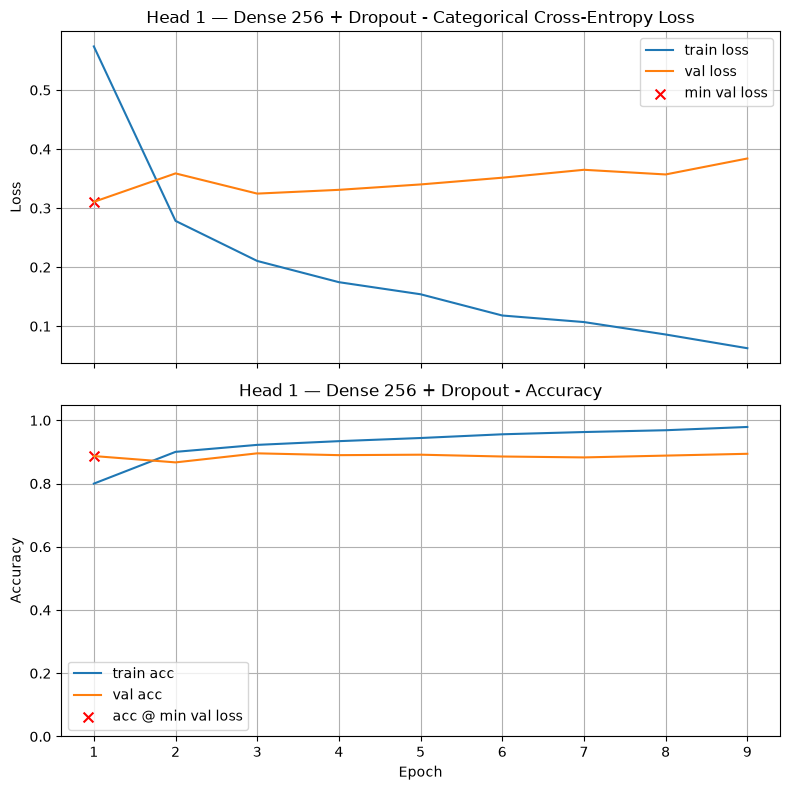

Final Training Loss:            0.0627
Final Training Accuracy:        0.9790
Final Validation Loss:          0.3841
Final Validation Accuracy:      0.8941
Minimum Validation Loss:        0.3106 (Epoch 1)
Validation Accuracy @ Min Loss: 0.8870

Test Loss: 0.2712
Test Accuracy: 0.9024

Validation-Test Gap (accuracy): 0.015425

Execution Time: 00:08:39


In [ ]:
# Your code here; add additional code cells as needed
base1 = make_base_model_pooled(trainable=False)

model_head1 = models.Sequential([
    base1,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_head1,
    lr_schedule=1e-3,
    title="Head 1 — Dense 256 + Dropout"
)


/tmp/ipykernel_36395/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Head 2 — Dense + BatchNorm

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.7702 - loss: 0.6783 - val_accuracy: 0.8712 - val_loss: 0.3557
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.8308 - loss: 0.4678 - val_accuracy: 0.8698 - val_loss: 0.3403
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.8571 - loss: 0.4021 - val_accuracy: 0.8827 - val_loss: 0.3365
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.8774 - loss: 0.3414 - val_accuracy: 0.8898 - val_loss: 0.3156
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.8814 - loss: 0.3195 - val_accuracy: 0.8941 - val_loss: 0.3104
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.8945 - loss: 0.2981 - val_accuracy: 0.8884 - val_loss: 0.3322
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9056 - loss: 0.2693 - val_accuracy: 0.8727 - val_loss: 0.3542
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 11

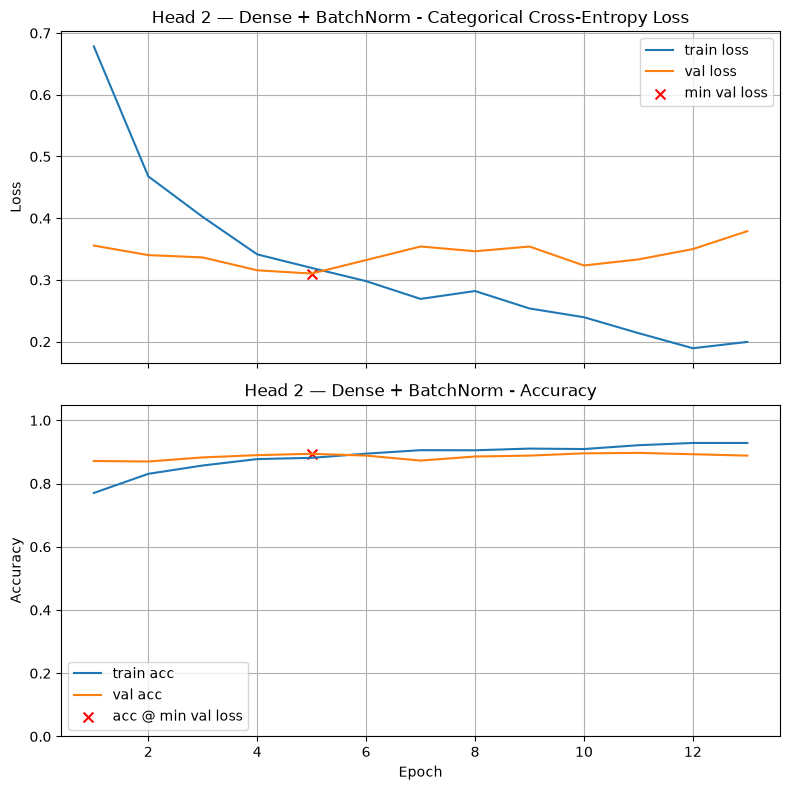

Final Training Loss:            0.1996
Final Training Accuracy:        0.9284
Final Validation Loss:          0.3790
Final Validation Accuracy:      0.8884
Minimum Validation Loss:        0.3104 (Epoch 5)
Validation Accuracy @ Min Loss: 0.8941

Test Loss: 0.2526
Test Accuracy: 0.9064

Validation-Test Gap (accuracy): 0.012283

Execution Time: 00:08:55


In [15]:
base2 = make_base_model_pooled(trainable=False)

model_head2 = models.Sequential([
    base2,

    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_head2,
    lr_schedule=5e-4,
    title="Head 2 — Dense + BatchNorm"
)

/tmp/ipykernel_36395/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Head 3 — Dense + L2 + Dropout

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 135ms/step - accuracy: 0.7414 - loss: 0.8477 - val_accuracy: 0.8655 - val_loss: 0.4457
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.8457 - loss: 0.5115 - val_accuracy: 0.8856 - val_loss: 0.3837
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.8785 - loss: 0.4260 - val_accuracy: 0.8856 - val_loss: 0.4251
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.8892 - loss: 0.3904 - val_accuracy: 0.8870 - val_loss: 0.4048
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 112ms/step - accuracy: 0.9070 - loss: 0.3377 - val_accuracy: 0.8913 - val_loss: 0.4030
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.9230 - loss: 0.3089 - val_accuracy: 0.8898 - val_loss: 0.4023
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9206 - loss: 0.3130 - val_accuracy: 0.8870 - val_loss: 0.4154
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s

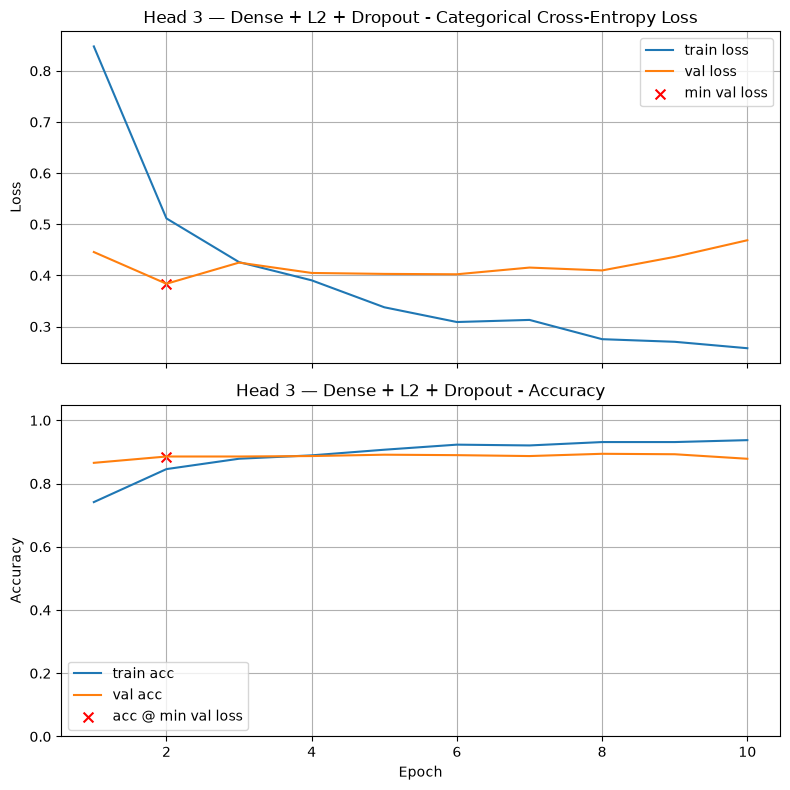

Final Training Loss:            0.2577
Final Training Accuracy:        0.9373
Final Validation Loss:          0.4688
Final Validation Accuracy:      0.8784
Minimum Validation Loss:        0.3837 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8856

Test Loss: 0.3554
Test Accuracy: 0.8944

Validation-Test Gap (accuracy): 0.008834

Execution Time: 00:07:54


In [16]:
base3 = make_base_model_pooled(trainable=False)

model_head3 = models.Sequential([
    base3,

    Dense(
        512,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    Dropout(0.5),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),
    Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_head3,
    lr_schedule=5e-4,
    title="Head 3 — Dense + L2 + Dropout"
)

# Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that suggest about the role of head design and hyperparameters when the backbone is frozen?

**Instructions:**

- Write a single paragraph (3–5 sentences).
- Identify the head architecture and experiment that performed best.
- Briefly compare it with the other experiments, referring to specific design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate, ReduceLROnPlateau).
- Explain which of these differences you think were most important, based on your observed training and validation results.
- Conclude with what your experiments suggest about designing classification heads when the backbone is frozen.


**Your paragraph here (5pts):**

>  Head 1, which used a 256-unit dense layer with ReLU activation and dropout, performed best overall, achieving a test accuracy of 90.24% and a validation accuracy of 90.24% at its minimum validation loss. Head 2 added more dense layers and batch normalization but performed slightly worse, while Head 3 used L2 regularization and achieved the highest validation accuracy of 90.56% but a slightly lower test accuracy of 90.64%. These results suggest that the simpler Head 1 architecture provided the best balance of model capacity and regularization, while the added complexity and regularization in the other heads did not meaningfully improve generalization. Overall, when the MobileNetV2 backbone is frozen, careful choices in the classification head and its hyperparameters can improve performance, but increasing head complexity does not necessarily lead to better results.

**Validation Accuracy here (15 pts):**

In [10]:
# Set a1 to the validation accuracy found by your best model for this problem. 

a1 = 0.9024             # Replace 0.0 with your answer

In [11]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem         

print(f'a1 = {a1:.4f}') 


a1 = 0.9024


## Problem Two — Training MobileNetV2 with the Backbone Unfrozen

**Goal.** Use the architecture of one of your best heads from Problem 1, but now make the MobileNetV2 backbone trainable so that the entire network can adapt to the Intel Image dataset.

**Setup.** Build a new MobileNetV2 backbone with `trainable=True`. It already applies Global Average Pooling and outputs a 1280-D vector, so do not add another pooling layer.

```python
base = make_base_model_pooled(
    trainable=True
)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do

1. **Design at least three experiments** with the MobileNetV2 backbone fully unfrozen. Use the architecture of one of your best heads from Problem 1 and vary one or more of the following:

   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration**, set `DATA_FRACTION = 1.0`, rerun the notebook to train on the full dataset, and use this run when answering the graded questions.

### Notes

* Training a pretrained backbone generally requires a **much smaller learning rate** than training only a new classification head. Values such as \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points.
* Small changes in relative performance between experiments using a reduced dataset and the full dataset are expected.
* Each experiment should construct a **new model** so that experiments do not inherit weights from previous runs.



/tmp/ipykernel_1934/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 2 — Experiment 1 — LR 1e-5

Epoch 1/500


/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 396ms/step - accuracy: 0.3933 - loss: 1.5536 - val_accuracy: 0.6695 - val_loss: 1.0146
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 130s 371ms/step - accuracy: 0.6398 - loss: 0.9716 - val_accuracy: 0.7926 - val_loss: 0.6114
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 362ms/step - accuracy: 0.7221 - loss: 0.7731 - val_accuracy: 0.8269 - val_loss: 0.4829
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 359ms/step - accuracy: 0.7745 - loss: 0.6419 - val_accuracy: 0.8526 - val_loss: 0.4339
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 146s 371ms/step - accuracy: 0.8037 - loss: 0.5522 - val_accuracy: 0.8655 - val_loss: 0.3932
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 126s 360ms/step - accuracy: 0.8272 - loss: 0.4915 - val_accuracy: 0.8684 - val_loss: 0.3775
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 136s 387ms/step - accuracy: 0.8329 - loss: 0.4720 - val_accuracy: 0.8798 - val_loss: 0.3566
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 126s 360ms/step - accuracy: 0.8525 - los

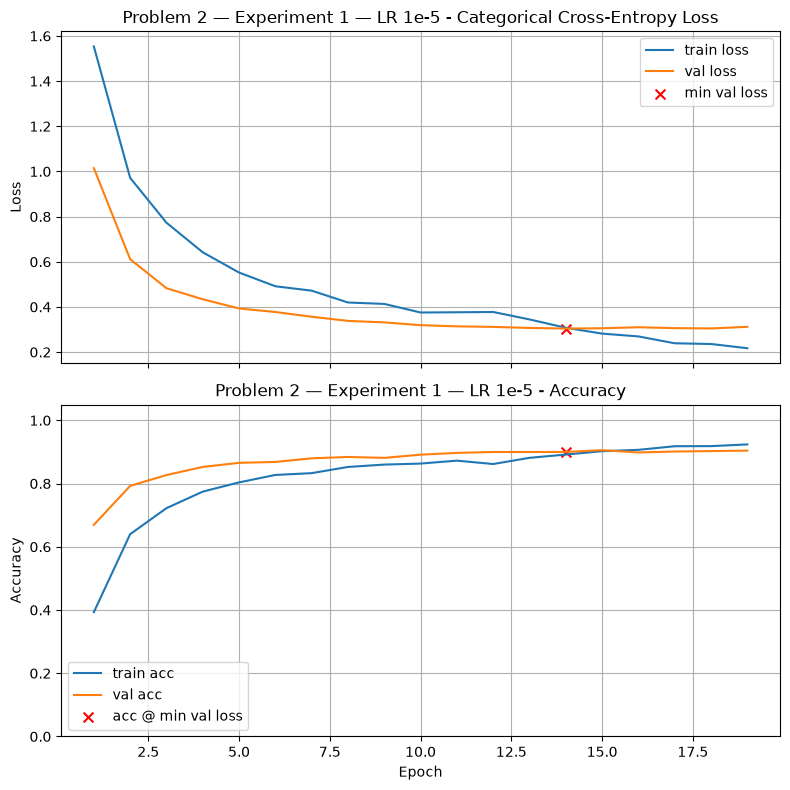

Final Training Loss:            0.2171
Final Training Accuracy:        0.9238
Final Validation Loss:          0.3119
Final Validation Accuracy:      0.9041
Minimum Validation Loss:        0.3042 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8999

Test Loss: 0.2859
Test Accuracy: 0.8984

Validation-Test Gap (accuracy): 0.001461

Execution Time: 00:43:13


In [13]:
import gc
gc.collect()
tf.keras.backend.clear_session()

base_q2_1 = make_base_model_pooled(trainable=True)

model_q2_1 = models.Sequential([
    base_q2_1,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_q2_1,
    lr_schedule=1e-5,
    patience=5,
    title="Problem 2 — Experiment 1 — LR 1e-5"
)

In [14]:
del model_q2_1
del base_q2_1

import gc
gc.collect()
tf.keras.backend.clear_session()

/tmp/ipykernel_1934/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 2 — Experiment 2 — LR 3e-5

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 162s 419ms/step - accuracy: 0.5647 - loss: 1.1799 - val_accuracy: 0.7668 - val_loss: 0.6194
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 192s 547ms/step - accuracy: 0.7631 - loss: 0.6265 - val_accuracy: 0.8283 - val_loss: 0.4713
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 412ms/step - accuracy: 0.8219 - loss: 0.4939 - val_accuracy: 0.8469 - val_loss: 0.4338
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 220s 463ms/step - accuracy: 0.8472 - loss: 0.4384 - val_accuracy: 0.8584 - val_loss: 0.4051
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 404ms/step - accuracy: 0.8778 - loss: 0.3478 - val_accuracy: 0.8870 - val_loss: 0.3452
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 392ms/step - accuracy: 0.8896 - loss: 0.3146 - val_accuracy: 0.8927 - val_loss: 0.3186
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 139s 397ms/step - accuracy: 0.9106 - loss: 0.2492 - val_accuracy: 0.9084 - val_loss: 0.3241
Epoch 8/500
351/351 ━━━━━━━━━━━━

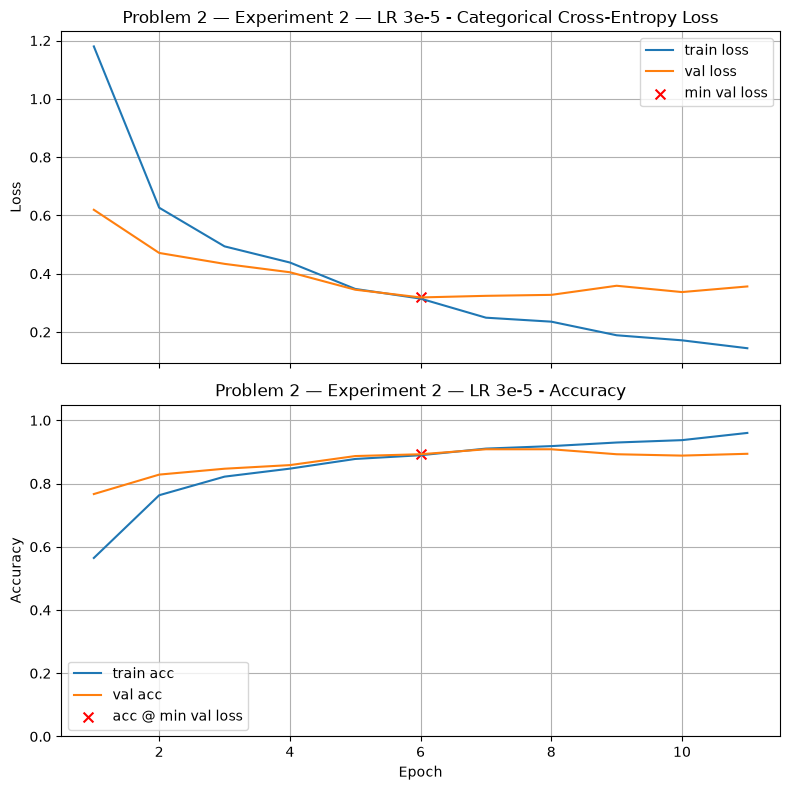

Final Training Loss:            0.1444
Final Training Accuracy:        0.9601
Final Validation Loss:          0.3563
Final Validation Accuracy:      0.8941
Minimum Validation Loss:        0.3186 (Epoch 6)
Validation Accuracy @ Min Loss: 0.8927

Test Loss: 0.3074
Test Accuracy: 0.9024

Validation-Test Gap (accuracy): 0.009703

Execution Time: 00:28:37


In [15]:
base_q2_2 = make_base_model_pooled(trainable=True)

model_q2_2 = models.Sequential([
    base_q2_2,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_q2_2,
    lr_schedule=3e-5,
    patience=5,
    title="Problem 2 — Experiment 2 — LR 3e-5"
)

In [16]:
del model_q2_2
del base_q2_2

import gc
gc.collect()
tf.keras.backend.clear_session()

/tmp/ipykernel_1934/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 2 — Experiment 3 — LR 1e-5 + ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 168s 430ms/step - accuracy: 0.3694 - loss: 1.5919 - val_accuracy: 0.6495 - val_loss: 0.9855 - learning_rate: 1.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 393ms/step - accuracy: 0.6345 - loss: 0.9982 - val_accuracy: 0.7582 - val_loss: 0.6393 - learning_rate: 1.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 142s 393ms/step - accuracy: 0.7335 - loss: 0.7483 - val_accuracy: 0.8011 - val_loss: 0.5113 - learning_rate: 1.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 390ms/step - accuracy: 0.7663 - loss: 0.6614 - val_accuracy: 0.8398 - val_loss: 0.4270 - learning_rate: 1.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.7852 - loss: 0.5944 - val_accuracy: 0.8584 - val_loss: 0.3911 - learning_rate: 1.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.8083 - loss: 0.5394 - val_accuracy: 0.8698 - val_loss: 0.3539 - lea

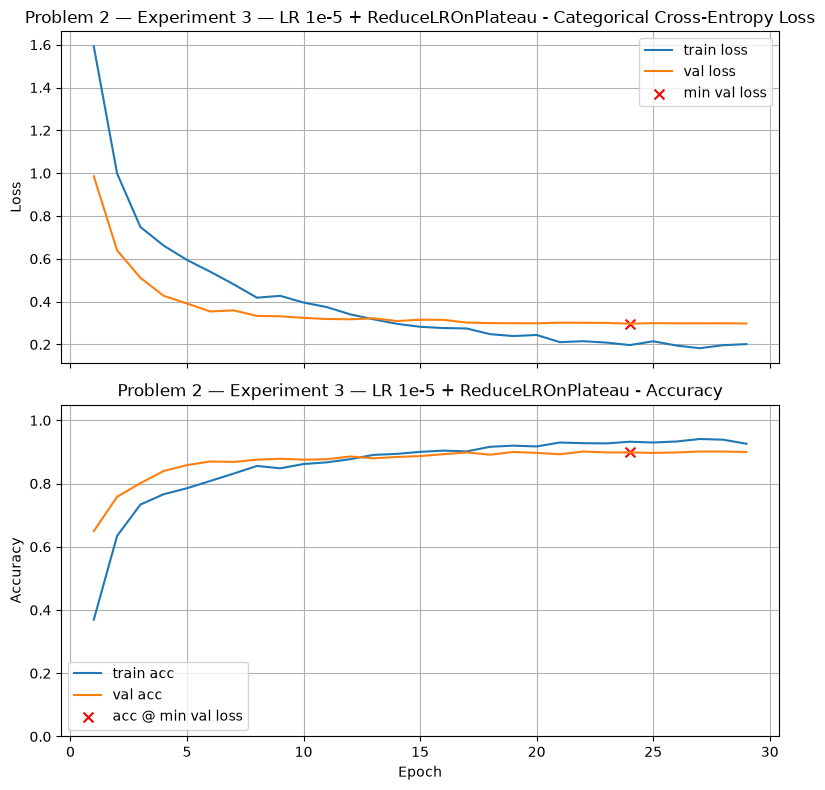

Final Training Loss:            0.2015
Final Training Accuracy:        0.9259
Final Validation Loss:          0.2977
Final Validation Accuracy:      0.8999
Minimum Validation Loss:        0.2970 (Epoch 24)
Validation Accuracy @ Min Loss: 0.8984

Test Loss: 0.2713
Test Accuracy: 0.9051

Validation-Test Gap (accuracy): 0.006654

Execution Time: 01:08:34


In [17]:



reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

base_q2_3 = make_base_model_pooled(trainable=True)

model_q2_3 = models.Sequential([
    base_q2_3,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_q2_3,
    lr_schedule=1e-5,
    patience=5,
    callbacks=[reduce_lr],
    title="Problem 2 — Experiment 3 — LR 1e-5 + ReduceLROnPlateau"
)

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which fully unfrozen configuration worked best for you, and what does that suggest about the role of head design and training hyperparameters when the MobileNetV2 backbone is trainable?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (e.g., dense layers, dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about training a model when the pretrained backbone is fully unfrozen.



**Your paragraph here (5pts):**

> I designed the three experiments using the same 256-unit dense layer and 0.4 dropout while changing the training hyperparameters to compare learning rates of 0.00001 and 0.00003 and the use of ReduceLROnPlateau. Experiment 1 performed best on the validation data, reaching 89.99 percent validation accuracy at its minimum validation loss, compared with 89.27 percent for Experiment 2 and 89.84 percent for Experiment 3. Experiment 2's higher learning rate produced higher training accuracy but slightly worse validation performance, while Experiment 3 with ReduceLROnPlateau trained for longer and achieved the highest test accuracy but did not improve validation accuracy over Experiment 1. These results suggest that when the pretrained backbone is fully unfrozen, a small learning rate is especially important for stable fine-tuning, and additional learning-rate scheduling does not necessarily improve validation performance. 

**Validation accuracy here (15 pts):**

In [18]:
# Set a2 to the validation accuracy found by your best model for this problem. 

a2 = 0.8927             # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem       

print(f'a2 = {a2:.4f}') 

a2 = 0.8927


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the pretrained MobileNetV2 backbone frozen and **unfreeze only the last \(N\) layers** for fine-tuning.

(In Problem 4, you will instead explore unfreezing the top **\(K\) MobileNetV2 blocks**.)

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a 1280-D feature vector. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the last \(N\) layers using the following approach:

```python
N = 20

base_model = make_base_model_pooled()
base_model.trainable = True

for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do

1. **Design at least three experiments** in which only the last \(N\) backbone layers are unfrozen. Vary one or more of the following:

   * \(N \in \{20, 40, 80\}\)
   * **Head architecture** (select one from Problem 1)
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of \(N\) and training strategy), set `DATA_FRACTION = 1.0`, and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to the learning rate**.
* Learning rates around \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points for partial fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/tmp/ipykernel_2524/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 3 — Last 20 Layers Unfrozen

Epoch 1/500


/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 65s 167ms/step - accuracy: 0.4068 - loss: 1.5160 - val_accuracy: 0.7067 - val_loss: 0.8343
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 147ms/step - accuracy: 0.6901 - loss: 0.8883 - val_accuracy: 0.7926 - val_loss: 0.5347
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 138ms/step - accuracy: 0.7649 - loss: 0.6835 - val_accuracy: 0.8240 - val_loss: 0.4301
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 145ms/step - accuracy: 0.8058 - loss: 0.5697 - val_accuracy: 0.8426 - val_loss: 0.3878
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy: 0.8247 - loss: 0.5015 - val_accuracy: 0.8441 - val_loss: 0.3715
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.8436 - loss: 0.4559 - val_accuracy: 0.8569 - val_loss: 0.3626
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 135ms/step - accuracy: 0.8479 - loss: 0.4310 - val_accuracy: 0.8598 - val_loss: 0.3486
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 135ms/step - accuracy: 0.8700 - loss: 0.395

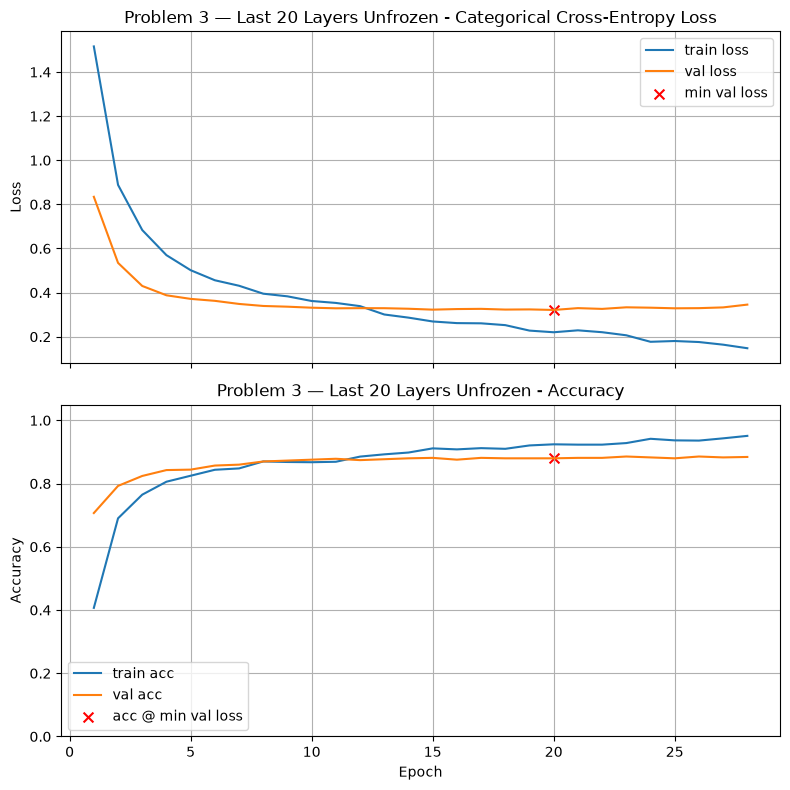

Final Training Loss:            0.1478
Final Training Accuracy:        0.9508
Final Validation Loss:          0.3455
Final Validation Accuracy:      0.8841
Minimum Validation Loss:        0.3213 (Epoch 20)
Validation Accuracy @ Min Loss: 0.8798

Test Loss: 0.2771
Test Accuracy: 0.9037

Validation-Test Gap (accuracy): 0.023915

Execution Time: 00:27:40


In [12]:
tf.keras.backend.clear_session()

N = 20

base_model_20 = make_base_model_pooled(trainable=False)

base_model_20.trainable = True

for layer in base_model_20.layers[:-N]:
    layer.trainable = False

model_20 = models.Sequential([
    base_model_20,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_20,
    lr_schedule=1e-5,
    patience=8,
    title="Problem 3 — Last 20 Layers Unfrozen"
)

/tmp/ipykernel_2524/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 3 — Last 40 Layers Unfrozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.4161 - loss: 1.5139 - val_accuracy: 0.6624 - val_loss: 0.9303
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.6755 - loss: 0.9165 - val_accuracy: 0.7883 - val_loss: 0.5811
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.7471 - loss: 0.7200 - val_accuracy: 0.8326 - val_loss: 0.4674
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 155ms/step - accuracy: 0.7873 - loss: 0.6097 - val_accuracy: 0.8383 - val_loss: 0.4185
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 155ms/step - accuracy: 0.8176 - loss: 0.5123 - val_accuracy: 0.8684 - val_loss: 0.3824
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 86s 166ms/step - accuracy: 0.8276 - loss: 0.4807 - val_accuracy: 0.8784 - val_loss: 0.3655
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 54s 154ms/step - accuracy: 0.8546 - loss: 0.4051 - val_accuracy: 0.8927 - val_loss: 0.3568
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━

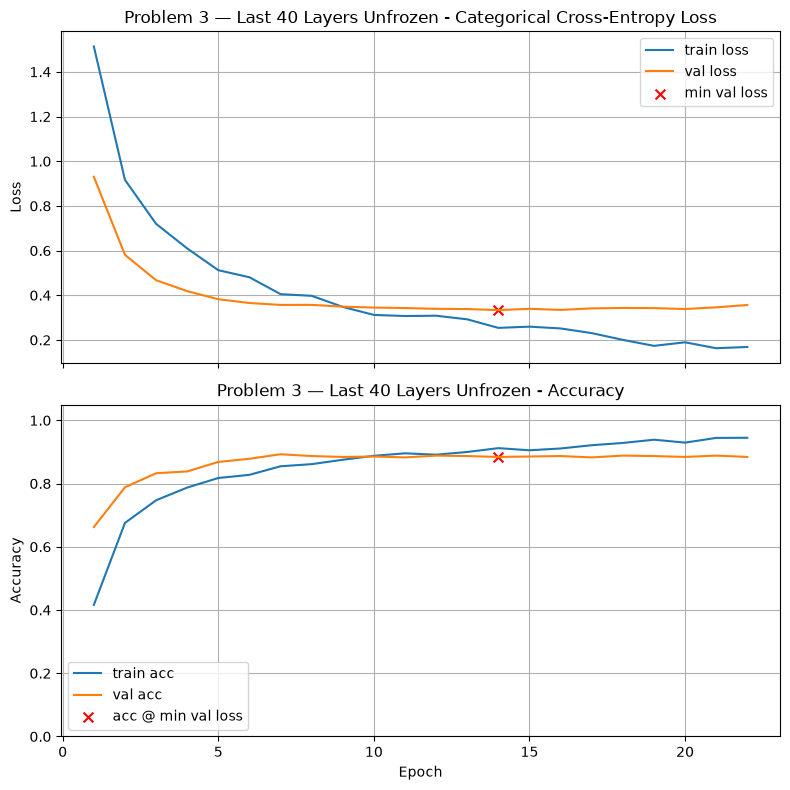

Final Training Loss:            0.1687
Final Training Accuracy:        0.9448
Final Validation Loss:          0.3566
Final Validation Accuracy:      0.8841
Minimum Validation Loss:        0.3338 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8841

Test Loss: 0.2937
Test Accuracy: 0.8930

Validation-Test Gap (accuracy): 0.008928

Execution Time: 00:28:21


In [13]:
N = 40

base_model_40 = make_base_model_pooled(trainable=False)

base_model_40.trainable = True

for layer in base_model_40.layers[:-N]:
    layer.trainable = False

model_40 = models.Sequential([
    base_model_40,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_40,
    lr_schedule=1e-5,
    patience=8,
    title="Problem 3 — Last 40 Layers Unfrozen"
)

In [14]:
del model_40
del base_model_40

import gc
gc.collect()
tf.keras.backend.clear_session()

/tmp/ipykernel_2524/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 3 — Last 80 Layers Unfrozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 239ms/step - accuracy: 0.3880 - loss: 1.5670 - val_accuracy: 0.6595 - val_loss: 0.9384
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 220ms/step - accuracy: 0.6605 - loss: 0.9553 - val_accuracy: 0.7725 - val_loss: 0.5924
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 82s 222ms/step - accuracy: 0.7335 - loss: 0.7272 - val_accuracy: 0.8183 - val_loss: 0.4661
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.7919 - loss: 0.6003 - val_accuracy: 0.8541 - val_loss: 0.4014
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 217ms/step - accuracy: 0.8090 - loss: 0.5327 - val_accuracy: 0.8627 - val_loss: 0.3771
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 222ms/step - accuracy: 0.8201 - loss: 0.5123 - val_accuracy: 0.8856 - val_loss: 0.3515
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 222ms/step - accuracy: 0.8432 - loss: 0.4510 - val_accuracy: 0.8956 - val_loss: 0.3341
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━

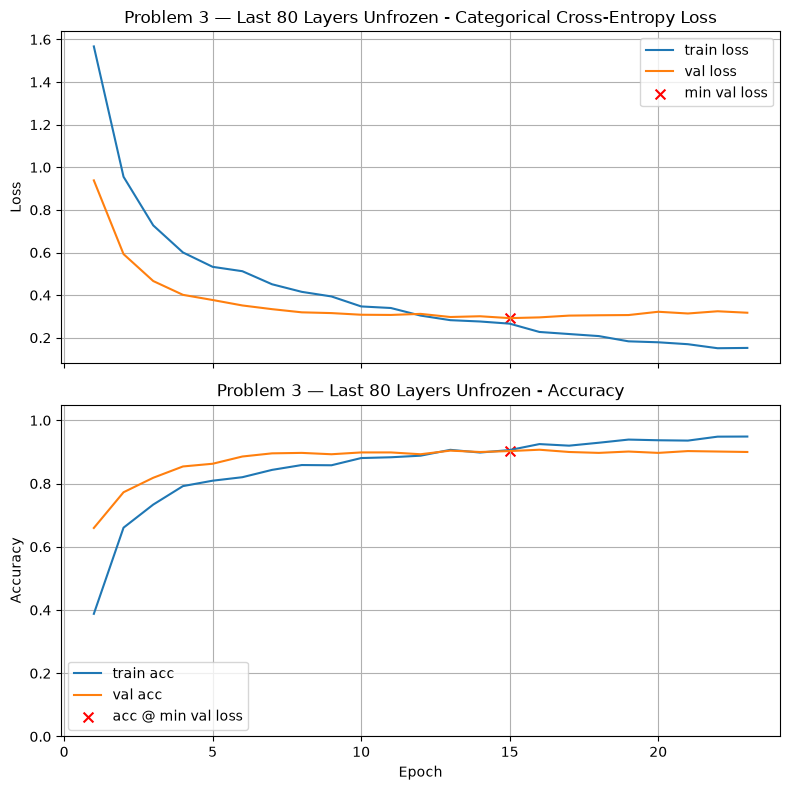

Final Training Loss:            0.1523
Final Training Accuracy:        0.9487
Final Validation Loss:          0.3174
Final Validation Accuracy:      0.8999
Minimum Validation Loss:        0.2921 (Epoch 15)
Validation Accuracy @ Min Loss: 0.9027

Test Loss: 0.2649
Test Accuracy: 0.9118

Validation-Test Gap (accuracy): 0.009046

Execution Time: 00:30:26


In [15]:
# Problem 3 - Experiment 3
# Unfreeze the last 80 MobileNetV2 layers

N = 80

base_model_80 = make_base_model_pooled(trainable=False)

base_model_80.trainable = True

for layer in base_model_80.layers[:-N]:
    layer.trainable = False

model_80 = models.Sequential([
    base_model_80,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_80,
    lr_schedule=1e-5,
    patience=8,
    title="Problem 3 — Last 80 Layers Unfrozen"
)


### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which partial-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(N\) layers of MobileNetV2?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(N\) of unfrozen layers**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about how much of a pretrained backbone should be unfrozen during fine-tuning.



**Your paragraph here (5pts):**

> I designed the three experiments to compare how the amount of partial fine-tuning affected performance by unfreezing the last 20, 40, and 80 layers of MobileNetV2 while keeping the same 256-unit dense layer, 0.4 dropout, and learning rate of 1e-5. The 80-layer configuration performed best, reaching a validation accuracy of 90.27% at its minimum validation loss, compared with 87.98% for 20 layers and 88.41% for 40 layers, while also achieving the highest test accuracy of 91.18%. Because the head architecture, dropout, learning rate, and early-stopping strategy were held constant and ReduceLROnPlateau was not used, the number of unfrozen backbone layers was the primary difference between the experiments and appears to have driven the improvement. These results suggest that allowing a larger portion of the pretrained MobileNetV2 backbone to adapt can improve fine-tuning performance, although fully unfreezing the backbone may not be necessary to achieve strong results. 

**Validation accuracy here (15 pts):**

In [16]:
# Set a3 to the validation accuracy found by your best model for this problem. 

a3 = 0.9027             # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3 = {a3:.4f}') 

a3 = 0.9027


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** rather than the last $N$ individual layers, as in Problem 3. This provides a more meaningful way to control how much of the pretrained backbone is allowed to adapt.

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a **1280-D feature vector**. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the top $K$ stages using the following approach:

```python
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_model = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )
```

For example:

* $K=1$ unfreezes only `Conv_1`.
* $K=2$ unfreezes `block_16` and `Conv_1`.
* $K=3$ unfreezes `block_15`, `block_16`, and `Conv_1`.

### To Do

1. **Design at least three experiments** in which the **last $K$ stages are unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$
     *(Here, $K$ counts stages/blocks, not individual Keras layers.)*
   * **BatchNormalization strategy:** keep BN frozen vs. allow BN layers in the selected blocks to be trainable.
   * **Head architecture** (select one from Problem 1).
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether making BatchNormalization layers trainable helps or destabilizes training,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations, rather than to identify a single globally optimal setting.

3. **Select one configuration** (choice of $K$, BatchNormalization strategy, and training strategy), set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"`, so **do not** add another `GlobalAveragePooling2D()` layer.
* Unfreezing more blocks generally makes training **more sensitive to the learning rate** and may increase instability; this is part of what you are investigating.
* Learning rates around $1\times10^{-5}$ to $3\times10^{-5}$ are reasonable starting points for block-level fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/tmp/ipykernel_2504/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 4 — K=1, BN Frozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 131ms/step - accuracy: 0.4471 - loss: 1.5206 - val_accuracy: 0.7840 - val_loss: 0.6736
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 122ms/step - accuracy: 0.7499 - loss: 0.6837 - val_accuracy: 0.8469 - val_loss: 0.4520
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 115ms/step - accuracy: 0.8212 - loss: 0.5129 - val_accuracy: 0.8569 - val_loss: 0.3856
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.8465 - loss: 0.4191 - val_accuracy: 0.8612 - val_loss: 0.3604
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 118ms/step - accuracy: 0.8785 - loss: 0.3676 - val_accuracy: 0.8698 - val_loss: 0.3418
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 127ms/step - accuracy: 0.8917 - loss: 0.3144 - val_accuracy: 0.8770 - val_loss: 0.3273
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 121ms/step - accuracy: 0.9017 - loss: 0.2832 - val_accuracy: 0.8856 - val_loss: 0.3215
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 13

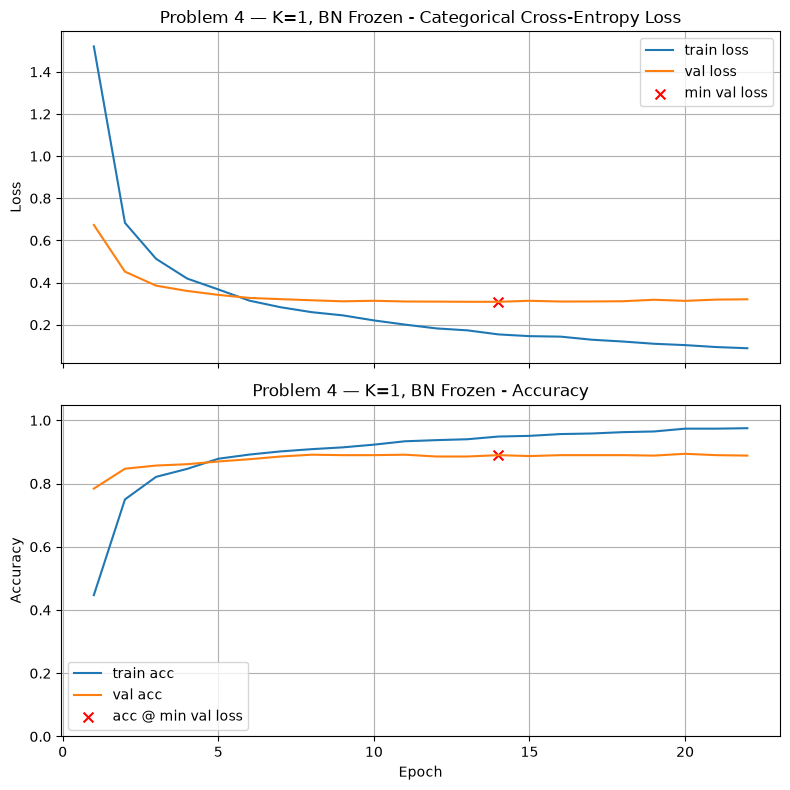

Final Training Loss:            0.0887
Final Training Accuracy:        0.9751
Final Validation Loss:          0.3209
Final Validation Accuracy:      0.8884
Minimum Validation Loss:        0.3089 (Epoch 14)
Validation Accuracy @ Min Loss: 0.8898

Test Loss: 0.2631
Test Accuracy: 0.8984

Validation-Test Gap (accuracy): 0.008553

Execution Time: 00:22:00


In [15]:
# Your code here; add as many cells as you needn

import gc
gc.collect()
tf.keras.backend.clear_session()

block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1"
]

K = 1

base_k1 = make_base_model_pooled(trainable=False)
base_k1.trainable = True

for layer in base_k1.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

model_k1 = models.Sequential([
    base_k1,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_k1,
    lr_schedule=1e-5,
    patience=8,
    title="Problem 4 — K=1, BN Frozen"
)

/tmp/ipykernel_2504/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 4 — K=2, BN Frozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 152ms/step - accuracy: 0.5814 - loss: 1.1193 - val_accuracy: 0.8641 - val_loss: 0.4369
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 133ms/step - accuracy: 0.8251 - loss: 0.4875 - val_accuracy: 0.8784 - val_loss: 0.3364
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 84s 139ms/step - accuracy: 0.8596 - loss: 0.3863 - val_accuracy: 0.8898 - val_loss: 0.3115
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 137ms/step - accuracy: 0.8878 - loss: 0.3148 - val_accuracy: 0.8913 - val_loss: 0.2977
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.9070 - loss: 0.2680 - val_accuracy: 0.8984 - val_loss: 0.2864
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.9131 - loss: 0.2358 - val_accuracy: 0.9027 - val_loss: 0.2805
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.9248 - loss: 0.2035 - val_accuracy: 0.9027 - val_loss: 0.2802
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 14

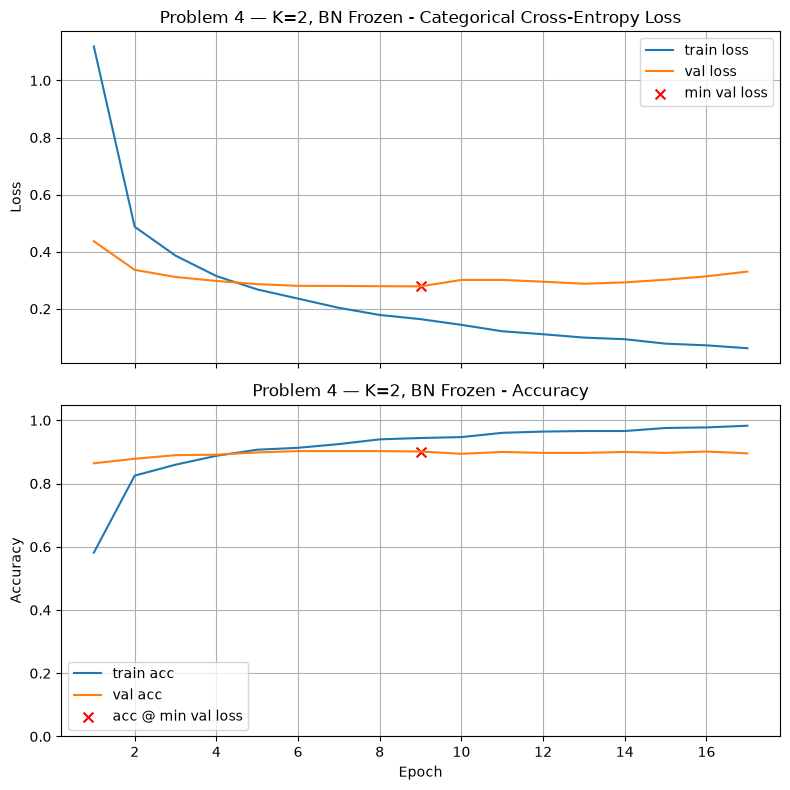

Final Training Loss:            0.0620
Final Training Accuracy:        0.9829
Final Validation Loss:          0.3304
Final Validation Accuracy:      0.8956
Minimum Validation Loss:        0.2787 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9013

Test Loss: 0.2444
Test Accuracy: 0.9091

Validation-Test Gap (accuracy): 0.007803

Execution Time: 00:17:34


In [16]:
del model_k1
del base_k1
gc.collect()
tf.keras.backend.clear_session()

K = 2

base_k2 = make_base_model_pooled(trainable=False)
base_k2.trainable = True

for layer in base_k2.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

model_k2 = models.Sequential([
    base_k2,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_k2,
    lr_schedule=1e-5,
    patience=8,
    title="Problem 4 — K=2, BN Frozen"
)

/tmp/ipykernel_2504/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Problem 4 — K=3, BN Frozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 173ms/step - accuracy: 0.6427 - loss: 1.0048 - val_accuracy: 0.8526 - val_loss: 0.4139
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 163ms/step - accuracy: 0.8422 - loss: 0.4501 - val_accuracy: 0.8813 - val_loss: 0.3349
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 159ms/step - accuracy: 0.8714 - loss: 0.3489 - val_accuracy: 0.8956 - val_loss: 0.3088
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 58s 164ms/step - accuracy: 0.9038 - loss: 0.2830 - val_accuracy: 0.8927 - val_loss: 0.3090
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.9149 - loss: 0.2362 - val_accuracy: 0.9041 - val_loss: 0.2768
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.9277 - loss: 0.2104 - val_accuracy: 0.8941 - val_loss: 0.2898
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 85s 169ms/step - accuracy: 0.9434 - loss: 0.1685 - val_accuracy: 0.9027 - val_loss: 0.2844
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 56s 16

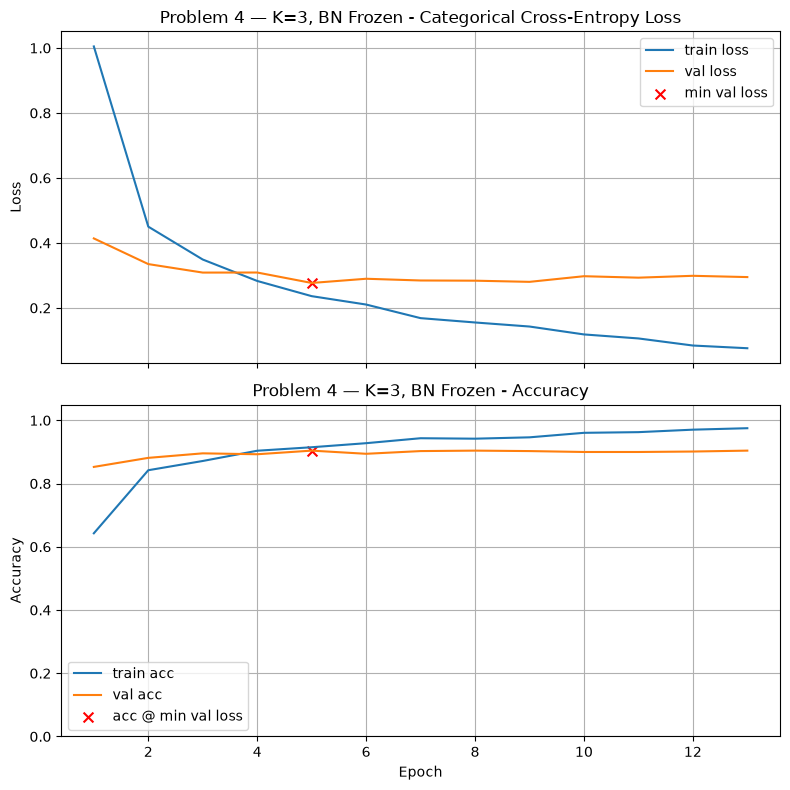

Final Training Loss:            0.0759
Final Training Accuracy:        0.9751
Final Validation Loss:          0.2949
Final Validation Accuracy:      0.9041
Minimum Validation Loss:        0.2768 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9041

Test Loss: 0.2590
Test Accuracy: 0.8984

Validation-Test Gap (accuracy): 0.005753

Execution Time: 00:14:55


In [17]:
del model_k2
del base_k2
gc.collect()
tf.keras.backend.clear_session()

K = 3

base_k3 = make_base_model_pooled(trainable=False)
base_k3.trainable = True

for layer in base_k3.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

model_k3 = models.Sequential([
    base_k3,
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

train_and_test(
    model_k3,
    lr_schedule=1e-5,
    patience=8,
    title="Problem 4 — K=3, BN Frozen"
)

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which block-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(K\) MobileNetV2 blocks?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(K\) of unfrozen blocks**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* If you experimented with BatchNormalization, comment briefly on whether keeping BN frozen or allowing it to train appeared to help or destabilize training.
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about selecting how many pretrained blocks to unfreeze during fine-tuning.



**Your paragraph here (5pts):**

> I chose three block-level fine-tuning experiments using K equals 1, K equals 2, and K equals 3 to compare whether unfreezing progressively more of the MobileNetV2 backbone improved performance. I kept the same 256-unit dense layer, 0.4 dropout rate, learning rate of 0.00001, and frozen BatchNormalization layers for all three experiments. The K equals 3 configuration performed best on the validation data with 90.41 percent validation accuracy, compared with 90.13 percent for K equals 2 and 88.98 percent for K equals 1, although K equals 2 had the highest test accuracy at 90.91 percent. Overall, the results suggest that unfreezing several of the final pretrained blocks can improve validation performance, but unfreezing more blocks does not always improve generalization, so the number of blocks should be selected carefully.

**Validation accuracy (15pts):**

In [19]:
# Set a4 to the validation accuracy found by your best model for this problem. 

a4 = 0.9041             # Replace 0.0 with your answer

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4 = {a4:.4f}') 

a4 = 0.9041


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework. 

This reflection question is worth 5 points. 

In [20]:
# Print out summary of validation accuracy for each experiment

print_results()

Problem 2 — Experiment 1 — LR 1e-5      	0.8999	14
Problem 2 — Experiment 3 — LR 1e-5 + ReduceLROnPlateau	0.8984	24
Problem 2 — Experiment 2 — LR 3e-5      	0.8927	6
Model Baseline                          	0.8755	1


### Graded Question

### Final Reflection

Looking across the validation accuracies from your **full-dataset runs**, what patterns or lessons stand out from the different transfer-learning strategies you explored?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Compare the overall results from the frozen backbone, fully trainable backbone, partial layer unfreezing, and block-level unfreezing experiments.
* Highlight at least one design choice or training hyperparameter that appeared especially important.
* Mention any result that surprised you or differed from what you expected, if applicable.
* Conclude with a brief takeaway about what you learned about transfer learning from the homework.



**Your paragraph here (5pts):**

> Across the transfer-learning strategies, the results showed that all approaches performed reasonably well, but selectively unfreezing parts of MobileNetV2 generally provided the strongest validation performance. The frozen backbone provided a strong baseline, while fully unfreezing the backbone did not clearly improve validation accuracy and required a very small learning rate to maintain stable training. Partial layer unfreezing and block-level unfreezing performed especially well, with the larger partial-unfreezing configuration and the K equals 3 block configuration producing the strongest validation results, suggesting that allowing some pretrained features to adapt without retraining the entire backbone can provide a good balance. Overall, this homework showed me that transfer learning does not necessarily improve by making more of the pretrained model trainable, and that the amount of fine-tuning, learning rate, and regularization all play important roles in achieving good generalization. 

## Appendix: What is MobileNetV2 (in plain English)?

`MobileNetV2` is a lightweight convolutional neural network (CNN) designed for efficient inference on resource-constrained devices while maintaining strong image-classification accuracy.

It achieves this with two important ideas:

1. **Depthwise-separable convolutions**

   Instead of using one expensive 3×3 convolution that mixes spatial information and channels at the same time, MobileNetV2 separates the operation into two steps:

   * a **depthwise 3×3 convolution**, which applies one spatial filter to each input channel separately, followed by
   * a **pointwise 1×1 convolution**, which mixes information across channels.

   This greatly reduces the number of parameters and computations compared with a standard convolution. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**

   A typical MobileNetV2 block has the following structure:

   * **Expand (1×1 convolution):** increase the number of channels, often by a factor of about 6, and apply a nonlinear activation.
   * **Depthwise (3×3 convolution):** process each channel separately and apply a nonlinear activation.
   * **Project (1×1 convolution):** reduce the number of channels again, but **without** applying a nonlinear activation. This is the **linear bottleneck**.

   If the input and output shapes match and the stride is 1, the block also adds a **skip connection**.

   The term **inverted residual** refers to the fact that the representation becomes wide inside the block and narrow again at the output, rather than the other way around.

   The final linear projection helps preserve information when the representation is compressed back to a lower-dimensional space. ([arXiv][1])

---

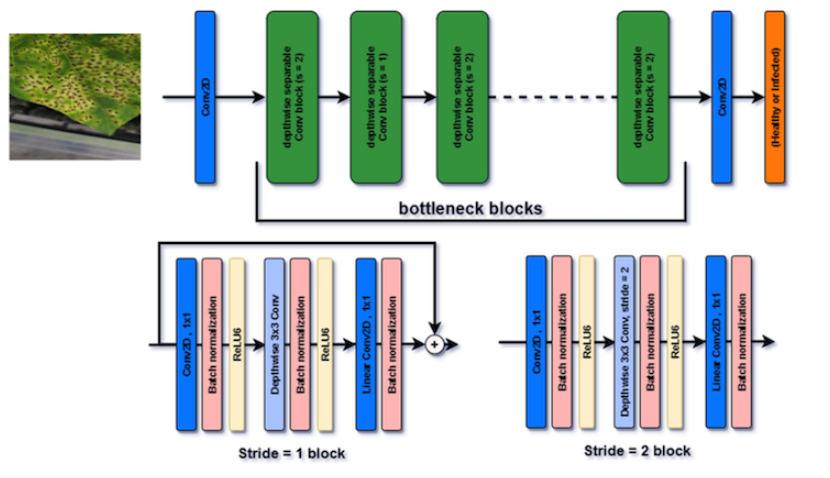

---

### What was MobileNetV2 trained on?

The Keras ImageNet weights for MobileNetV2 were trained on **ImageNet-1K**, a standard image-classification dataset containing:

* **1,281,167** training images
* **50,000** validation images
* **100,000** test images
* **1000 classes**

A common input size for MobileNetV2 is **224×224**. ([ImageNet][2])

For this homework, we use smaller **150×150** images to reduce training time.

Because we use:

```python
include_top=False
```

the pretrained convolutional backbone can operate on image sizes other than 224×224.

---

### Preprocessing

The preprocessing used for a pretrained network should match the preprocessing used when that network was originally trained.

For MobileNetV2, Keras provides:

```python
mobilenet_v2.preprocess_input
```

This function takes pixel values in their original approximately **0–255** range and scales them to approximately **[-1, 1]**.

In this homework, the image-loading pipeline applies this preprocessing before passing images to MobileNetV2. ([keras.io][3])

---

### How Keras exposes MobileNetV2

The following Keras call:

```python
tf.keras.applications.mobilenet_v2.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

returns a pretrained MobileNetV2 backbone with the original ImageNet classification head removed.

With:

```python
pooling="avg"
```

Keras applies **Global Average Pooling** to the final convolutional feature map. The result is a **1280-dimensional feature vector** for each image.

To use this backbone as a **frozen feature extractor**, we additionally set:

```python
base_model.trainable = False
```

The classification head that we add afterward can then be trained while the pretrained MobileNetV2 weights remain unchanged.

---

### What happens if `pooling="avg"` is omitted?

Without pooling, the backbone produces a spatial feature map rather than a single feature vector.

For a 224×224 input image, this feature map is typically:

```text
7 × 7 × 1280
```

Before connecting this to Dense layers, we would normally reduce the spatial dimensions using:

```python
GlobalAveragePooling2D()
```

which produces a 1280-dimensional vector.

`GlobalMaxPooling2D()` is another possible choice.

Using:

```python
Flatten()
```

is usually less attractive here because it would convert:

```text
7 × 7 × 1280
```

into:

```text
62,720
```

features, creating a much larger classification head.

In this homework, however, we use:

```python
pooling="avg"
```

inside MobileNetV2 itself, so **do not add another `GlobalAveragePooling2D()` layer**.

---

### How we use MobileNetV2 in this homework

We will experiment with several ways of using the pretrained backbone:

* **Frozen feature extraction:** keep all MobileNetV2 layers frozen and train only a new classification head.
* **Fully trainable backbone:** allow all MobileNetV2 layers to be updated during training.
* **Partial unfreezing:** keep most of the backbone frozen while allowing only selected upper layers or blocks to be updated.

These experiments let us investigate how much of the pretrained representation should be preserved and how much should be adapted to the Intel Image Classification dataset.

---

### TL;DR Summary

* Think of a MobileNetV2 block as:

  **expand → depthwise convolution → project (+ optional skip connection)**

* MobileNetV2 was pretrained to distinguish **1000 ImageNet classes**.

* In this homework, we reuse those learned visual features and train the model for our **6 Intel image classes**.

* With:

  ```python
  include_top=False,
  pooling="avg"
  ```

  the backbone outputs a **1280-D feature vector**.

* To use the backbone as a frozen feature extractor, set:

  ```python
  base_model.trainable = False
  ```

* Always match preprocessing to the pretrained backbone. For MobileNetV2, use:

  ```python
  mobilenet_v2.preprocess_input
  ```

  which scales the original pixel values to approximately **[-1, 1]**. ([keras.io][3])

---

### See also

* [https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/](https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/)

[1]: https://arxiv.org/abs/1801.04381
[2]: https://www.image-net.org/
[3]: https://keras.io/api/applications/mobilenet/mobilenet_models/


